## Imports and functions

In [1]:
# -------------------------------------------------------------------
# 1) Standard library and environment utilities
# -------------------------------------------------------------------
import os
from datetime import datetime
from math import floor, log

# -------------------------------------------------------------------
# 2) Data / numerical analysis stack
# -------------------------------------------------------------------
import numpy as np
import pandas as pd

# -------------------------------------------------------------------
# 3) Plotting and visualization
# -------------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns
from pylab import rcParams

# -------------------------------------------------------------------
# 4) Time series and statistics
# -------------------------------------------------------------------
from scipy import signal
from scipy.stats import norm, pearsonr, rankdata
from statsmodels.tsa import seasonal
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller, ccf, grangercausalitytests

# -------------------------------------------------------------------
# 5) Machine learning and preprocessing
# -------------------------------------------------------------------
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFE, SelectFromModel
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# -------------------------------------------------------------------
# 6) BigQuery client dependencies (kept for compatibility with existing workflow)
# -------------------------------------------------------------------
# from google.cloud import bigquery, bigquery_storage
from pandas_gbq import to_gbq

# -------------------------------------------------------------------
# 7) Project utilities: move reusable helper functions to analysis_utils.py
# -------------------------------------------------------------------
from analysis_utils import (
    append_csv_to_dataframe,
    adjusted_r2,
    bic,
    ccf_funct,
    cross_correlate,
    detrender,
    dual_plot_corr,
    evaluate_model,
    forward_fill_increment,
    lagged_corr_plot,
    lin_model,
    plot_ccf_2,
    robust_r2_score,
    roll_apply_max_ccf,
    series_rel_plot,
    twinplot,
    LinearModelClass,
)

# Notebook plotting defaults
rcParams['figure.figsize'] = 12, 5

# Common plotting color scheme
color1 = 'black'
color2 = 'grey'
color3 = '#ffcc00'
f = 12 * 1e6

## Data manipulation

### Intro

In [2]:
directory_path = "C:/Users/illoi/Escritorio-2/00 - RETAIL INSIGHTS & ANALYTICS/01 - MARKET ANALYSIS/Data/US - Copy/FRED"
result_df, series_dict = append_csv_to_dataframe(directory_path)

# result_df.fillna(0, inplace=True)
result_df.index = pd.to_datetime(result_df.index)

# result_df.head()

CO - CB CCI.csv
CO - Household PCE.csv
CO - Michigan CSI.csv
CO - PCE Durable goods Furnishings and durable household equipment.csv
CO - PCE.csv
CO - PCEDG PCE Durable goods.csv
CO - PCEDGC96 Real PCE Durable goods Chain-type.csv
CO - PCEPI PCE Chain-type.csv
CO - PCEPILFE PCE Excl Food and Energy Chain-Type.csv
CO - Real Households Final PCE.csv
DEBT - Household Debt Service Percent of Disp Income.csv
DEBT - Household Financial Obligations as a Percent of Disposable Personal Income.csv
DEBT - Outstanding debt.csv
DEBT - Total Mortgages Asset, Level.csv
EMP - All Employees, Total Nonfarm PAYEMS.csv
EMP - Labor Force Total From 15 to 64 Years for United States.csv
EMP - Unemployment Rate.csv
GROSS - GDP.csv
GROSS - GDP_infl_adj.csv
GROSS - Households.csv
GROSS - Housing.csv
GROSS - Population, Total for United States.csv
GROSS - SP500 Index.csv
GROSS - SP500 PER.csv
H - Consumer Price Index- Rent.csv
H - New Houses Sold.csv
H - Rent of Primary Residence.csv
H - US Existing home sales.cs

c:\Users\illoi\Escritorio-2\GIT PR\econ_insights_repo\analysis_utils.py:216: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  series.index = pd.to_datetime(series.index)


INF - HF CPI.csv
INF - Inflation, consumer prices.csv
INF - Sticky CPI.csv
IR - 3-Month Eurodollar Deposit Rate.csv
IR - 3-Month TB Secondary Market Rate.csv
IR - FEDFUNDS.csv
IR - MORTGAGE15US.csv
IR - MORTGAGE30US.csv
MON - FED balance sheet.csv
MON - LOANS.csv
MON - M2SL.csv
MON - TOTLL.csv
MON - USDEUR.csv
MON - USDGBP.csv
Y - Retail Sales Furniture & HF.csv


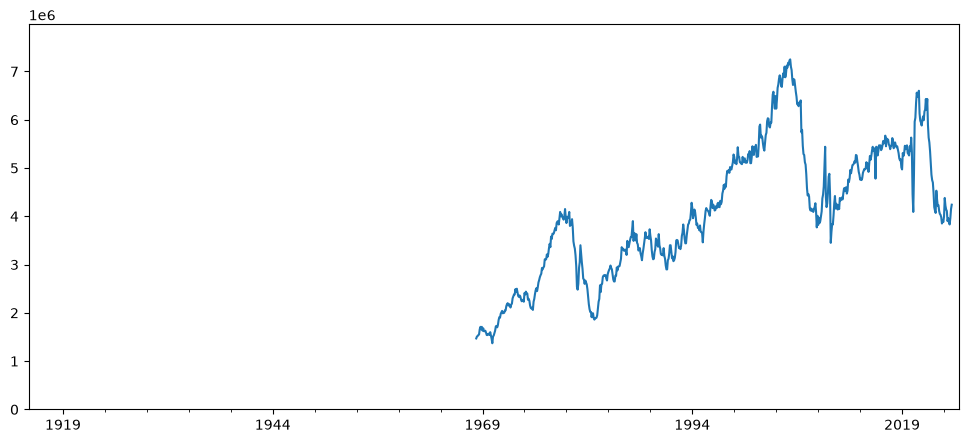

In [3]:
result_df['US Existing home sales'].plot()
plt.ylim((0,1.1 * series_dict['US Existing home sales'].max()));

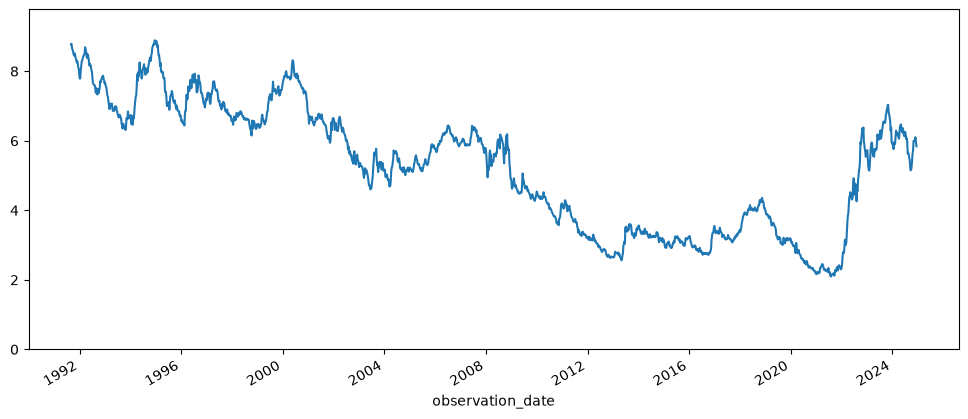

In [4]:
series_dict['MORTGAGE15US'].plot()
plt.ylim((0,1.1 * series_dict['MORTGAGE15US'].max()));

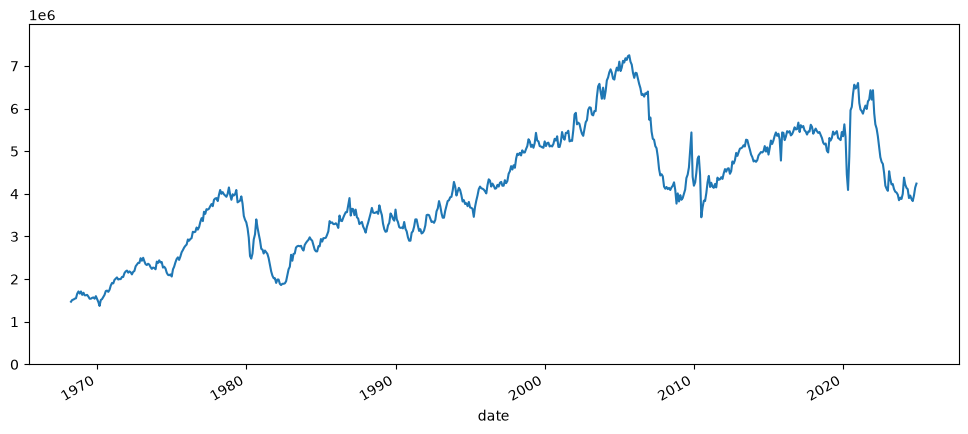

In [5]:
series_dict['US Existing home sales'].plot()
plt.ylim((0,1.1 * series_dict['US Existing home sales'].max()));

### NA

<Axes: >

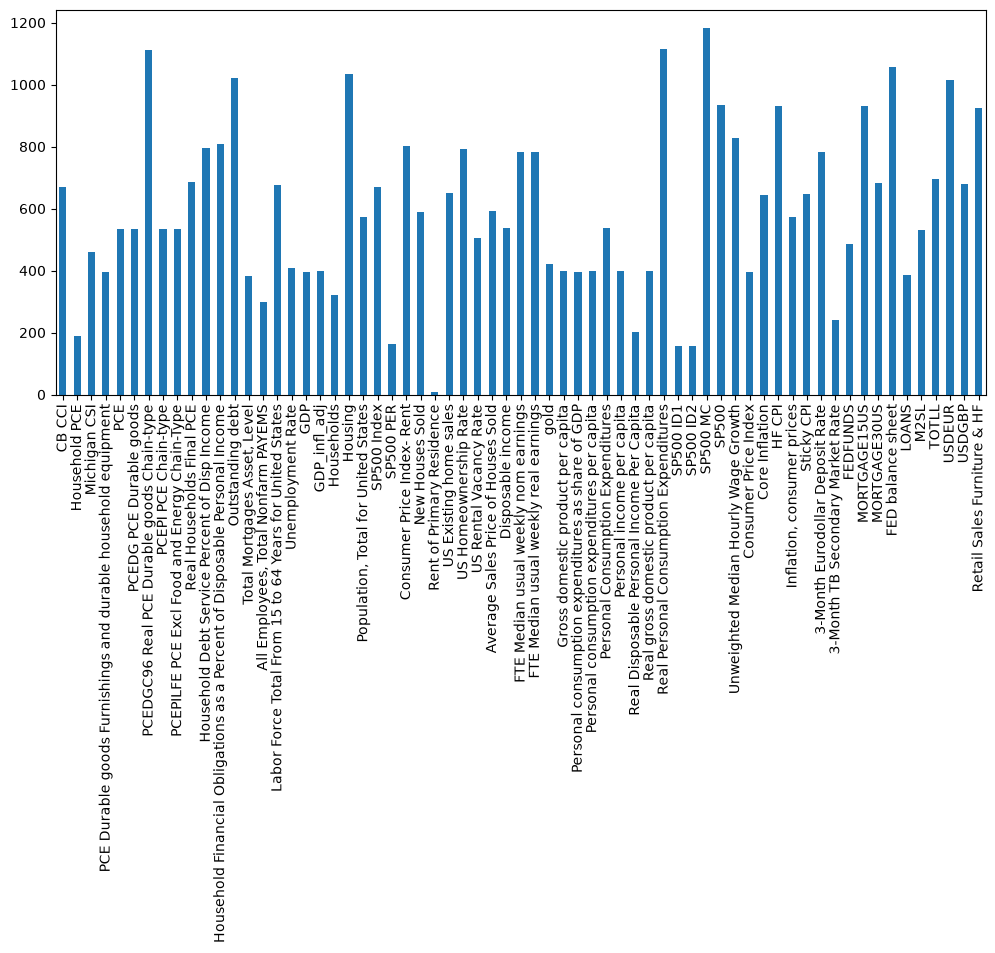

In [6]:
result_df.isna().sum().plot(kind='bar')

<Axes: >

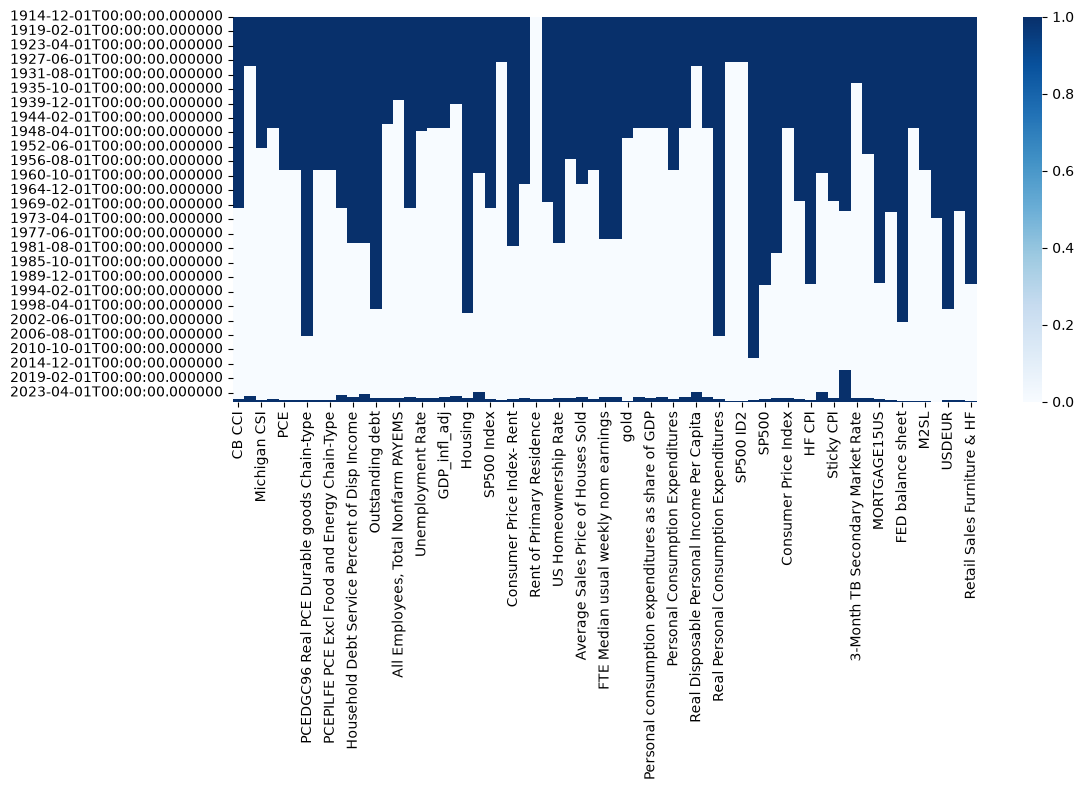

In [7]:
sns.heatmap(result_df.isna().astype('int'), cmap='Blues')

<Axes: >

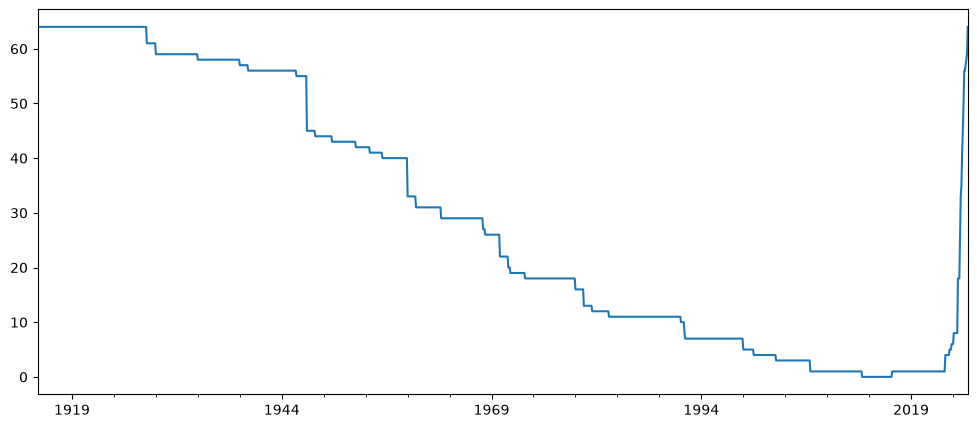

In [8]:
na_series = result_df.isna().sum(axis=1)

na_series[na_series==0]

na_series.plot()

### Export

In [9]:
exit_path = "C:/Users/illoi/Escritorio-2/00 - RETAIL INSIGHTS & ANALYTICS/01 - MARKET ANALYSIS/Data/US - Copy"
file_name = 'prov.csv'
sep = ','

result_df.to_csv(os.path.join(exit_path, file_name), sep=sep)

### New df - since 1992

In [10]:
df = result_df[~result_df['Retail Sales Furniture & HF'].isna()].copy()

In [11]:
# df[['FEDFUNDS','MORTGAGE15US']].corr()
# df[['MORTGAGE15US','US All home sales']].corr()
# df[df.index.year>2009][['MORTGAGE15US','US All home sales']].corr()

### Population correction

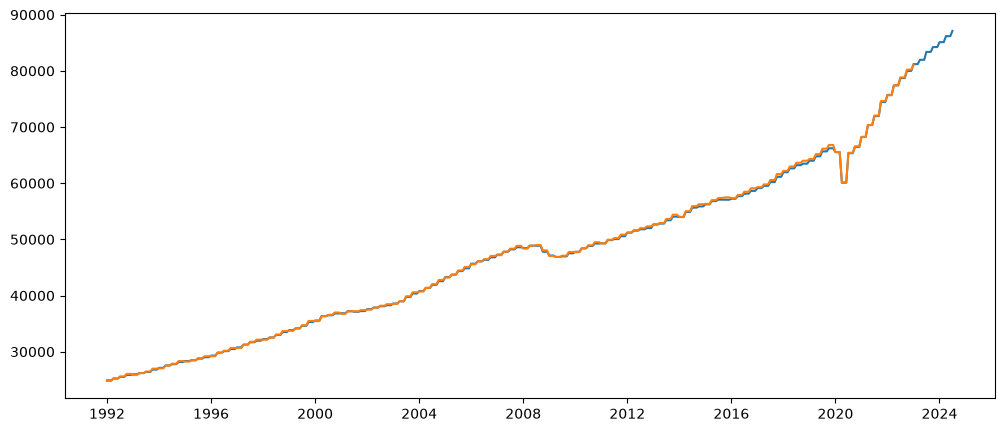

In [12]:
plt.plot(df['Gross domestic product per capita'])
plt.plot(df['GDP'] / df['Population, Total for United States'] * 1e9)

<Axes: >

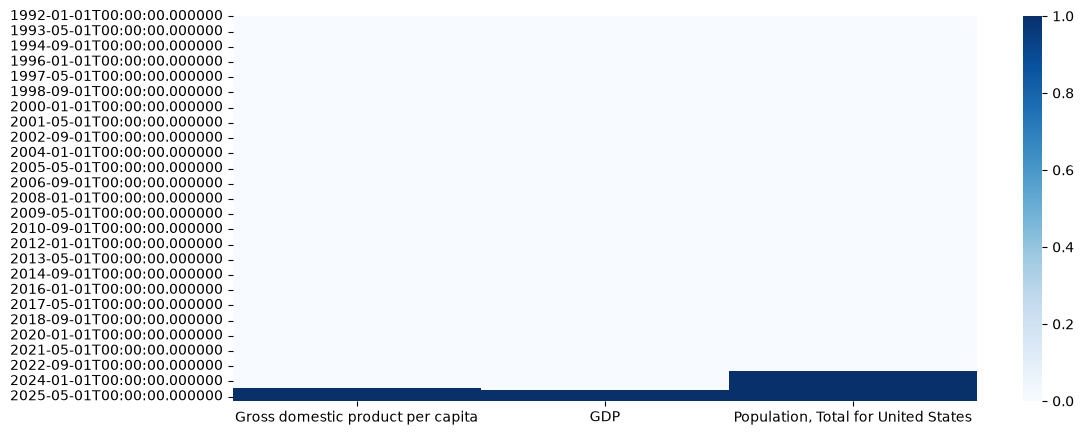

In [13]:
sns.heatmap(df[['Gross domestic product per capita','GDP','Population, Total for United States']].isna(), cmap='Blues')

In [14]:
calc = 1e9 * df['GDP'] / df['Gross domestic product per capita']
df.fillna({'Population, Total for United States': calc}, inplace=True)

,CB CCI,Household PCE,Michigan CSI,PCE Durable goods Furnishings and durable household equipment,PCE,PCEDG PCE Durable goods,PCEDGC96 Real PCE Durable goods Chain-type,PCEPI PCE Chain-type,PCEPILFE PCE Excl Food and Energy Chain-Type,Real Households Final PCE,...,FEDFUNDS,MORTGAGE15US,MORTGAGE30US,FED balance sheet,LOANS,M2SL,TOTLL,USDEUR,USDGBP,Retail Sales Furniture & HF
1992-01-01,52.5,4109.625,67.5,121.980,4084.7,495.6,NaN,62.638,63.641,1607342.5,...,4.03,8.0060,8.4320,NaN,2042.0160,3381.2,2041.892320,NaN,1.808981,3699.0
1992-02-01,50.2,4109.625,68.8,121.980,4099.5,501.3,NaN,62.797,63.814,1607342.5,...,4.06,8.3825,8.7625,NaN,2039.1062,3400.0,2039.452000,NaN,1.777842,3759.0
1992-03-01,47.3,4109.625,76.0,121.980,4117.0,491.7,NaN,62.949,63.973,1607342.5,...,3.98,8.5775,8.9350,NaN,2038.8427,3403.9,2037.126175,NaN,1.723836,3997.0
1992-04-01,56.5,4109.625,77.2,122.968,4131.5,490.0,NaN,63.119,64.183,1616605.0,...,3.73,8.4700,8.8525,NaN,2039.8128,3399.7,2041.043220,NaN,1.756623,3981.0
1992-05-01,65.1,4109.625,79.2,122.968,4158.4,501.9,NaN,63.203,64.273,1616605.0,...,3.82,8.2940,8.6720,NaN,2036.1467,3398.6,2037.059125,NaN,1.809485,4109.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-05-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,6696532.25,12871.0110,21883.9,12855.138925,NaN,NaN,11766.0
2025-06-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,6673324.00,12922.3097,22021.4,12897.092250,NaN,NaN,11044.0
2025-07-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,6656215.20,12984.0013,22115.4,12973.279260,NaN,NaN,11044.0
2025-08-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,6626564.25,13032.6804,NaN,13030.506075,NaN,NaN,11044.0


In [15]:
df['Population'] = (1e9 * df['GDP'] / df['Gross domestic product per capita']).rolling(window=12, min_periods=1, center=True).mean()

,"Population, Total for United States",Population
1992-01-01,256514000.0,2.560139e+08
1992-02-01,256514000.0,2.562097e+08
1992-03-01,256514000.0,2.563565e+08
1992-04-01,256514000.0,2.564706e+08
1992-05-01,256514000.0,2.566511e+08


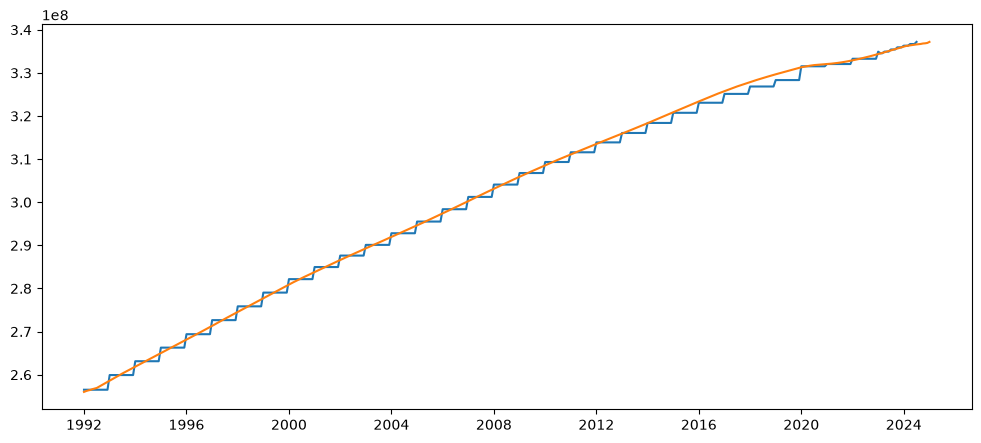

In [16]:
plt.plot(df['Population, Total for United States'])
plt.plot(df['Population'])
df[['Population, Total for United States', 'Population']].head()

In [17]:
df['Population_growth'] = df['Population'].diff().bfill()

In [18]:
df.drop(columns='Population, Total for United States', inplace=True)

### Employees

PearsonRResult(statistic=np.float64(0.7285828220711015), pvalue=np.float64(6.552911311547807e-66))

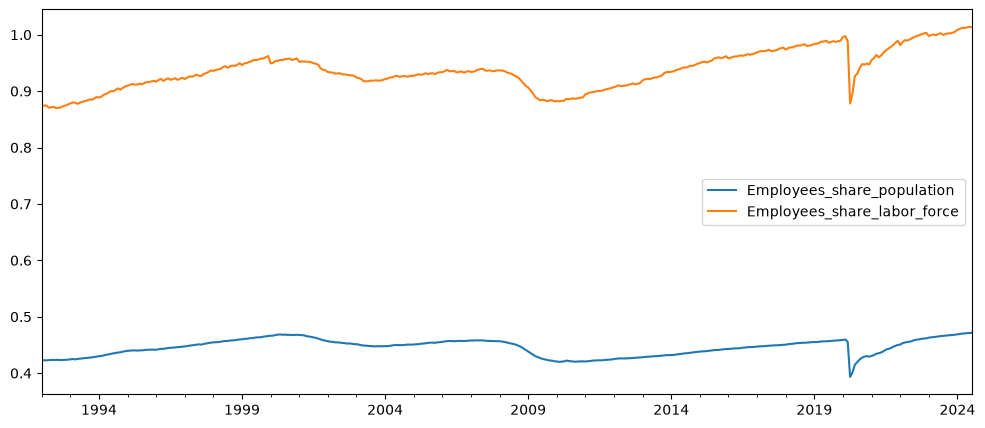

In [19]:
df['Employees_share_labor_force'] = df['All Employees, Total Nonfarm PAYEMS'] / df['Labor Force Total From 15 to 64 Years for United States'] * 1e3
df['Employees_share_population'] = df['All Employees, Total Nonfarm PAYEMS'] / df['Population'] * 1e3

aux_df = df[['Employees_share_population', 'Employees_share_labor_force']].dropna()
aux_df.plot()
# plt.ylim([0,1])
plt.legend()
pearsonr(aux_df['Employees_share_population'], aux_df['Employees_share_labor_force'])

PearsonRResult(statistic=np.float64(0.9581873648239568), pvalue=np.float64(6.012853216335444e-213))

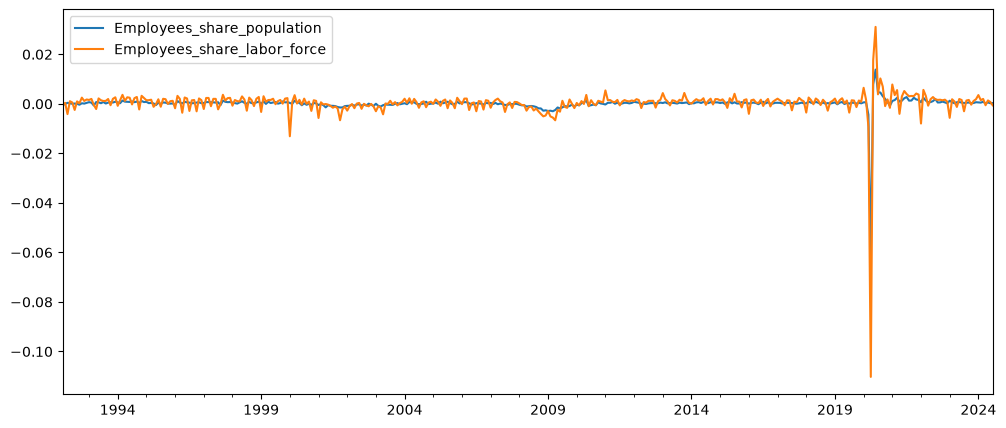

In [20]:
aux_df = df[['Employees_share_population', 'Employees_share_labor_force']].diff().dropna()
aux_df.plot()
plt.legend()
pearsonr(aux_df['Employees_share_population'], aux_df['Employees_share_labor_force'])

<Axes: >

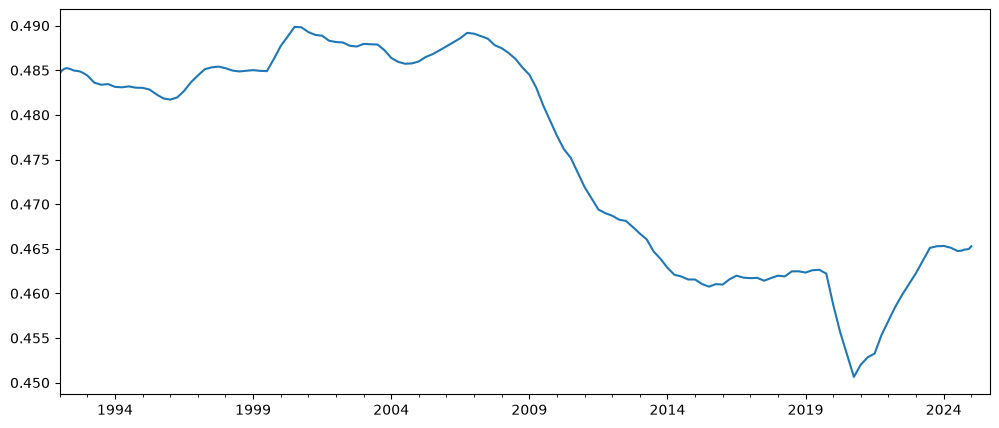

In [21]:
(df['Labor Force Total From 15 to 64 Years for United States'] / df['Population']).rolling(window=12, min_periods=1, center=True).mean().plot()

### GDP smoothing

<Axes: >

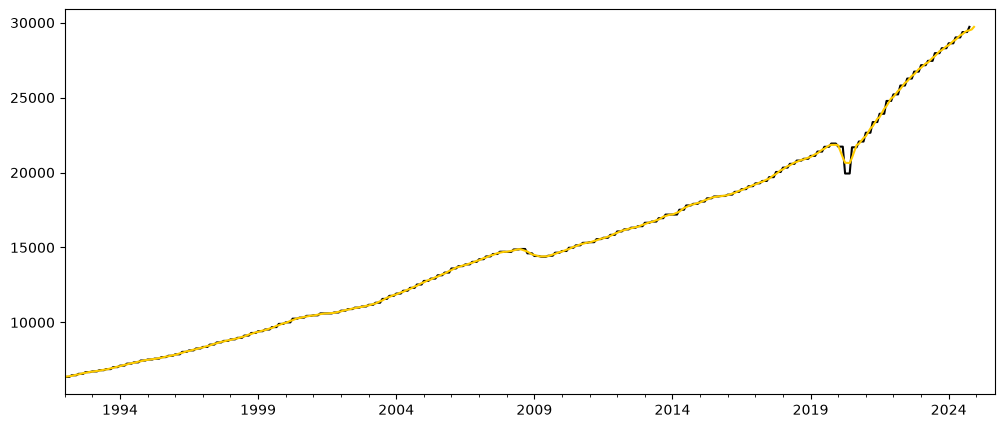

In [22]:
df['GDP'].plot(color=color1)
df['GDP'].rolling(window=5, min_periods=1, center=True).mean().plot(color=color3)

In [23]:
df['GDP'] = df['GDP'].rolling(window=5, min_periods=1, center=True).mean()
df['GDP_infl_adj'] = df['GDP_infl_adj'].rolling(window=5, min_periods=1, center=True).mean()

### Housing

<Axes: >

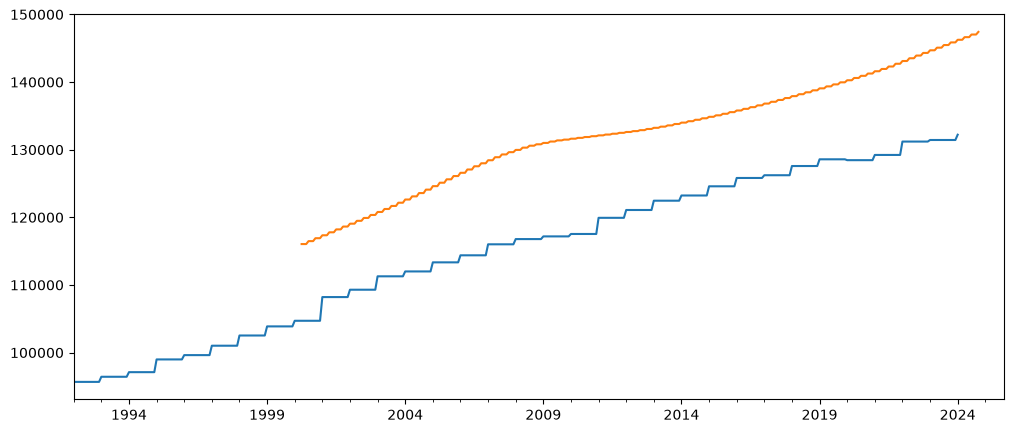

In [24]:
df['Households'].plot()
df['Housing'].plot()

<Axes: >

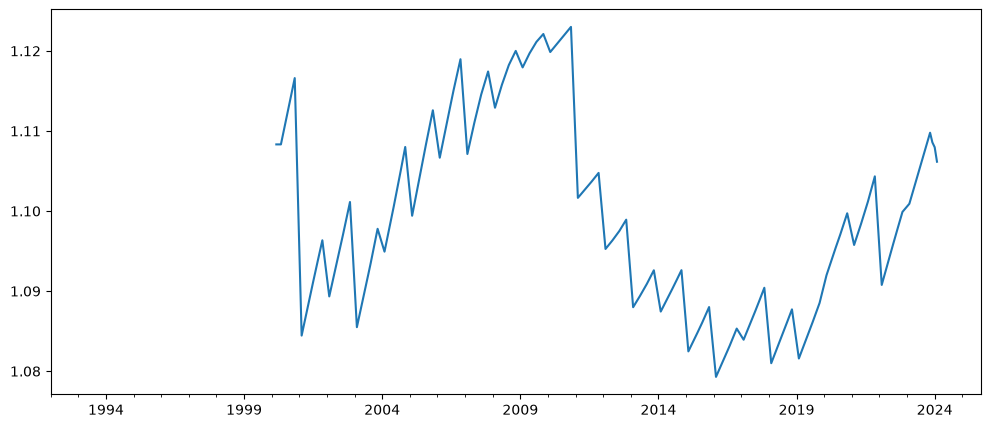

In [25]:
(df['Housing'] / df['Households']).rolling(window=3, min_periods=1, center=True).mean().plot()
# plt.ylim([0,1.2])

<Axes: >

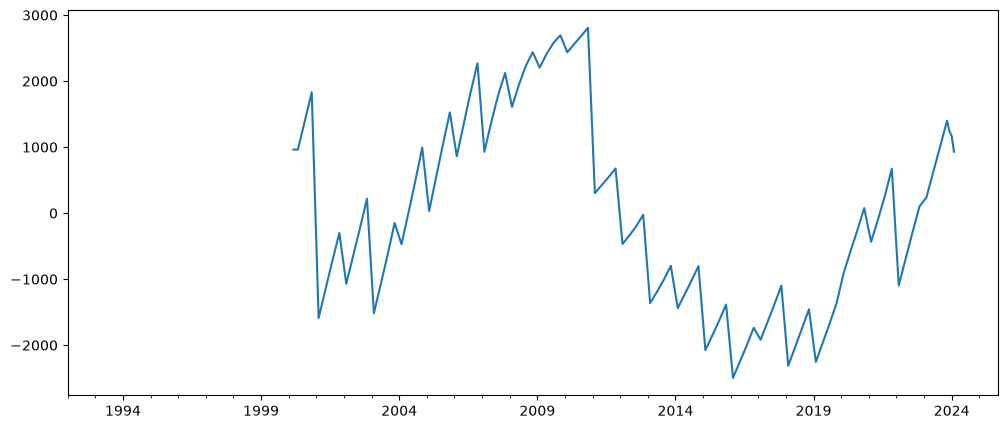

In [26]:
h_to_h_factor = (df['Housing'] / df['Households']).mean()
(df['Housing'] - h_to_h_factor * df['Households']).rolling(window=3, min_periods=1, center=True).mean().plot()

In [27]:
df['Households'] = 1e3 * df['Households'].rolling(window=12, min_periods=1, center=True).mean()
df['Housing'] = 1e3 * df['Housing'].ffill().rolling(window=12, min_periods=1, center=True).mean()

116757.14285714286
116047000.0


<Axes: >

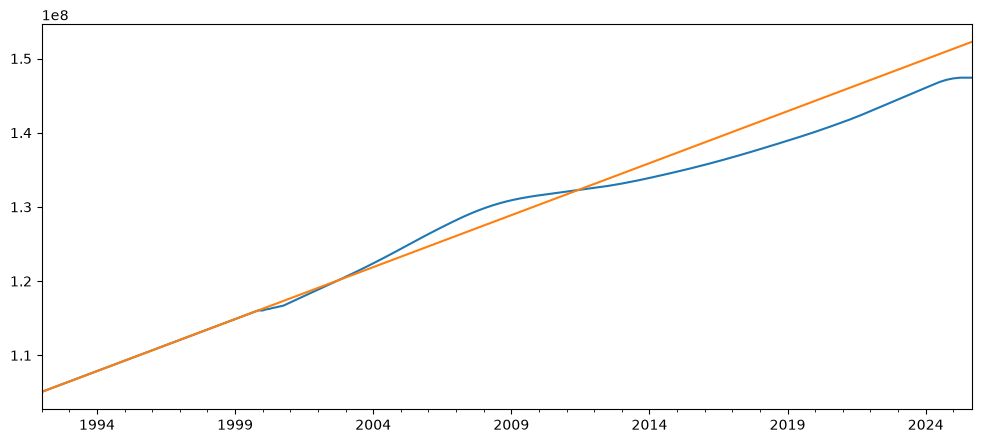

In [28]:
non_null = df['Housing'].dropna()
trend = non_null[:36].diff().mean()
print(trend)
print(non_null.iloc[0])
fill_series = pd.Series((np.arange(0, len(df)) - df['Housing'].reset_index().dropna().index[0]) * trend + non_null.iloc[0], index=df.index)
# df['Housing'].plot()
# fill_series.plot()
df['Corr_Housing'] = df['Housing'].fillna(fill_series)
# df['Corr_Housing_2'] = df['Housing'].fillna(1.1*df['Households']).rolling(window=3, min_periods=1, center=True).mean()

# df['Corr_Housing'] = (df['Corr_Housing'] + df['Corr_Housing_2']) / 2

df['Corr_Housing'].plot()
# df['Corr_Housing_2'].plot()
fill_series.plot()

<Axes: >

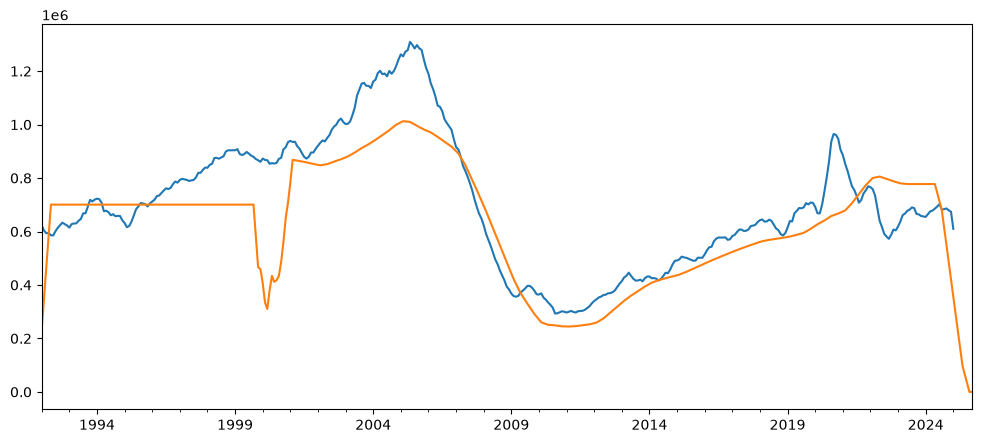

In [29]:
df['New Houses Sold'].rolling(window=6, min_periods=1, center=True).mean().plot()
(df['Corr_Housing'].diff().rolling(window=6, min_periods=1, center=True).sum()).plot()

In [30]:
df['Housing_minus_households'] = (df['Corr_Housing'] - df['Households']).rolling(window=6, min_periods=1, center=True).mean()
df['Housing_to_households'] = (df['Corr_Housing'] /  df['Households']).rolling(window=6, min_periods=1, center=True).mean()

<Axes: >

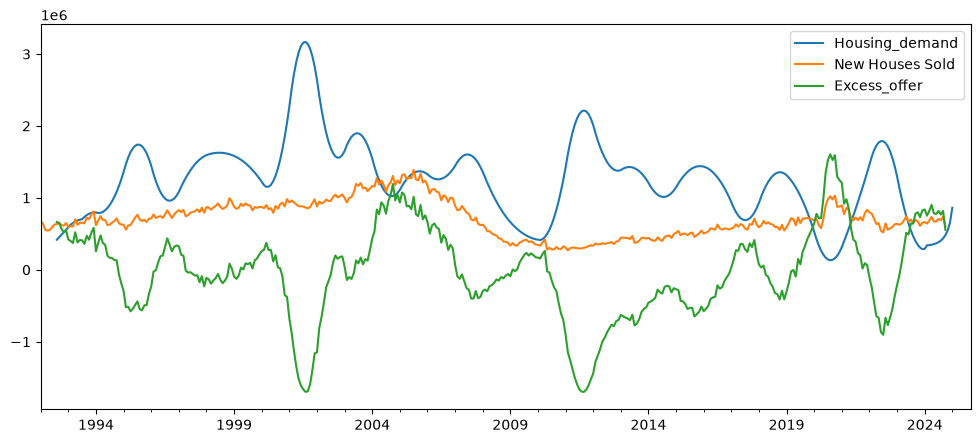

In [31]:
df['Housing_demand'] = (df['Households'].diff(12) * df['Housing_to_households'].mean()).rolling(window=12, min_periods=1, center=True).mean()

df['Excess_offer'] = 1.7 * df['New Houses Sold'] - df['Housing_demand']
df[['Housing_demand', 'New Houses Sold', 'Excess_offer']].plot()

<Axes: >

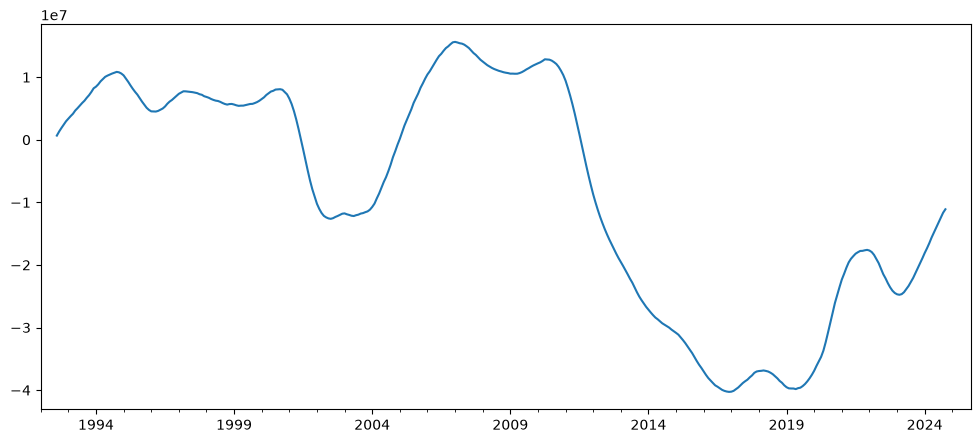

In [32]:
df['Excess_housing'] = df['Excess_offer'].cumsum()
df['Excess_housing'].plot()

np.float64(0.14124415455865605)

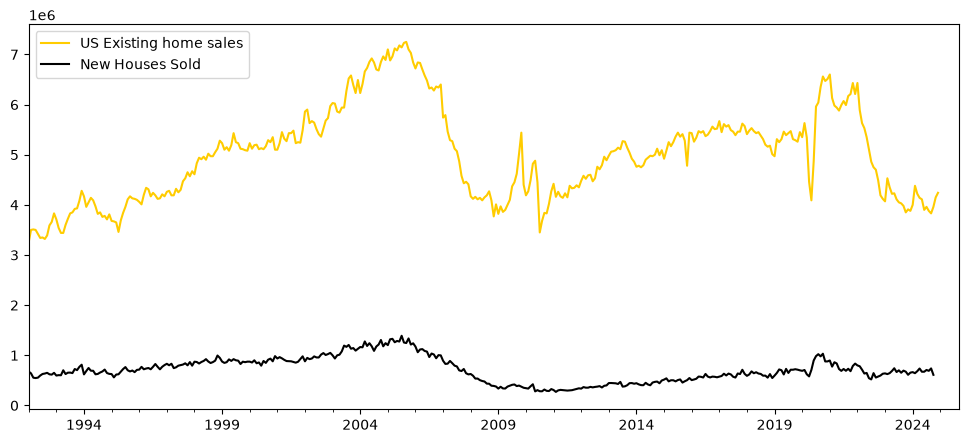

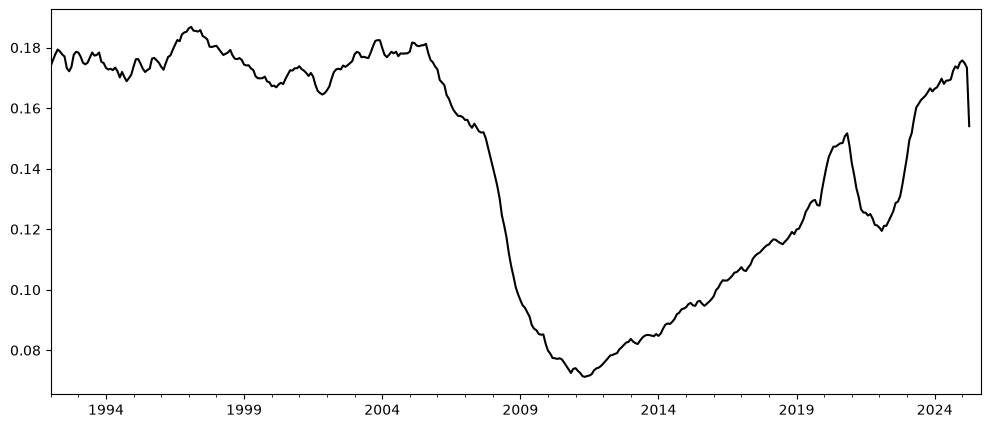

In [33]:
df[['US Existing home sales', 'New Houses Sold']].plot(color=[color3, color1])
plt.figure()
(df['New Houses Sold']/df['US Existing home sales']).rolling(window=12, min_periods=1, center=True).mean().plot(color=color1)
(df['New Houses Sold']/df['US Existing home sales']).mean()

np.float64(0.17707226824543693)

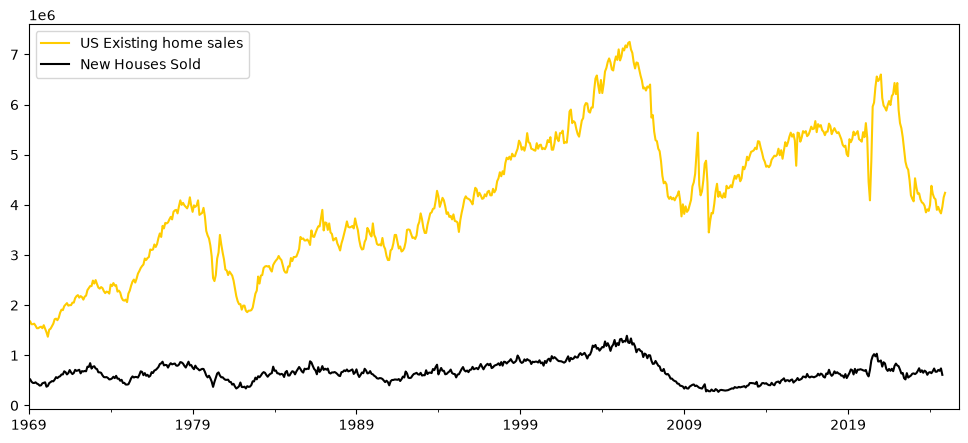

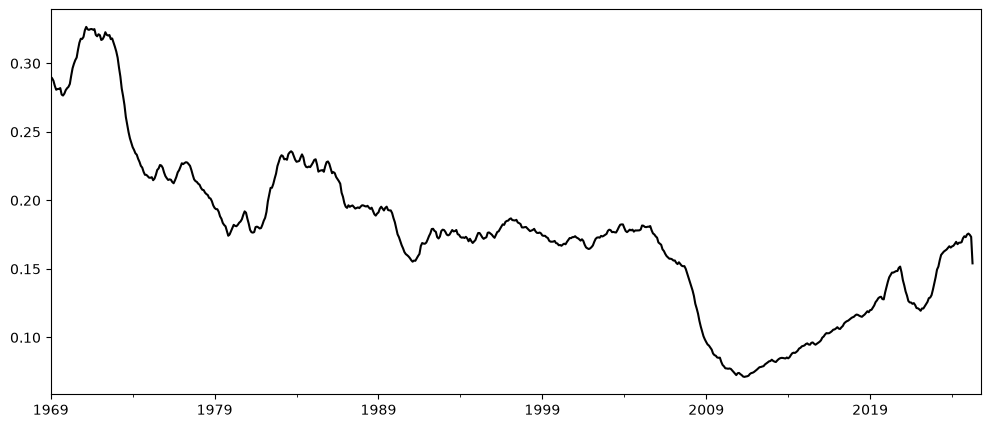

In [34]:
result_df.loc['01-01-1969':, ['US Existing home sales', 'New Houses Sold']].plot(color=[color3, color1])
plt.figure()
(result_df['New Houses Sold']/result_df['US Existing home sales'])['01-01-1969':].rolling(window=12, min_periods=1, center=True).mean().plot(color='k')
(result_df['New Houses Sold']/result_df['US Existing home sales']).mean()

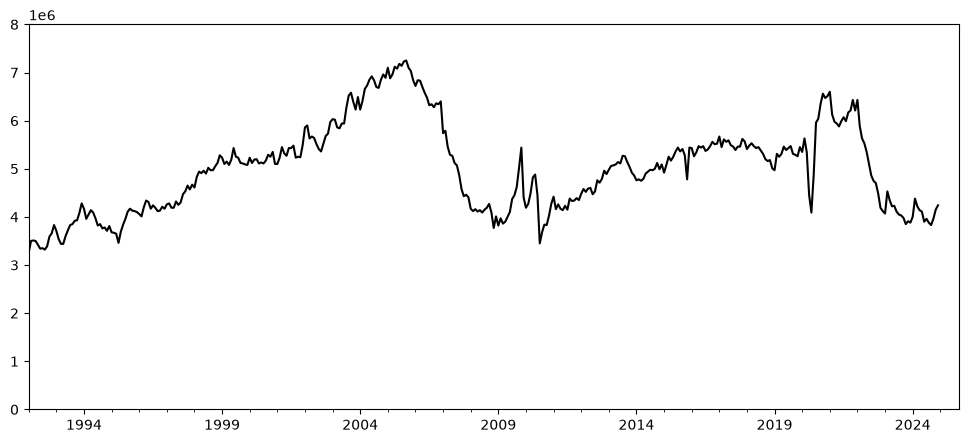

In [35]:
df['US All home sales'] = df['US Existing home sales'] + df['New Houses Sold']
df['US Existing home sales'].plot(color=color1)
plt.ylim([0,8e6]);

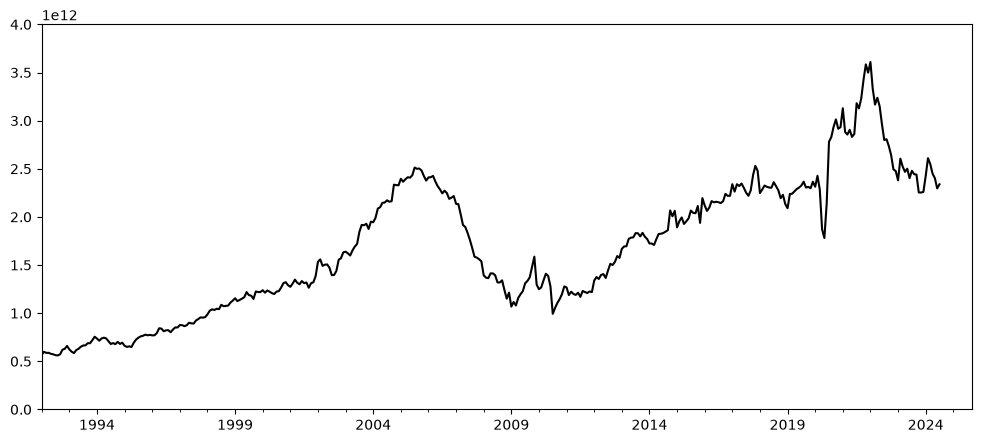

In [36]:
df['Real Estate - market sales'] = df['US All home sales'] * df['Average Sales Price of Houses Sold']
df['Real Estate - market sales'].plot(color='black')
plt.ylim([0,4e12]);

<Axes: >

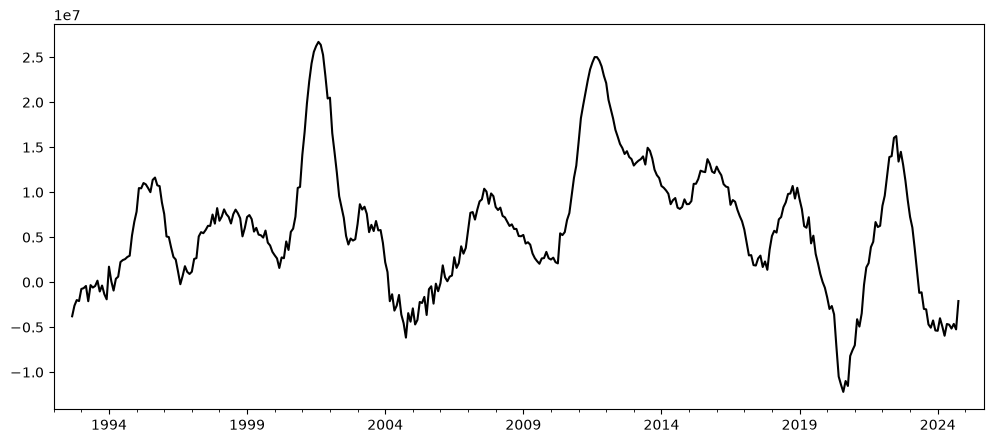

In [37]:
df['Adj_US All home sales'] = df['US All home sales'] - 12 * df['Excess_housing'].diff()
df['Adj_US All home sales'].plot(color='black')

<Axes: >

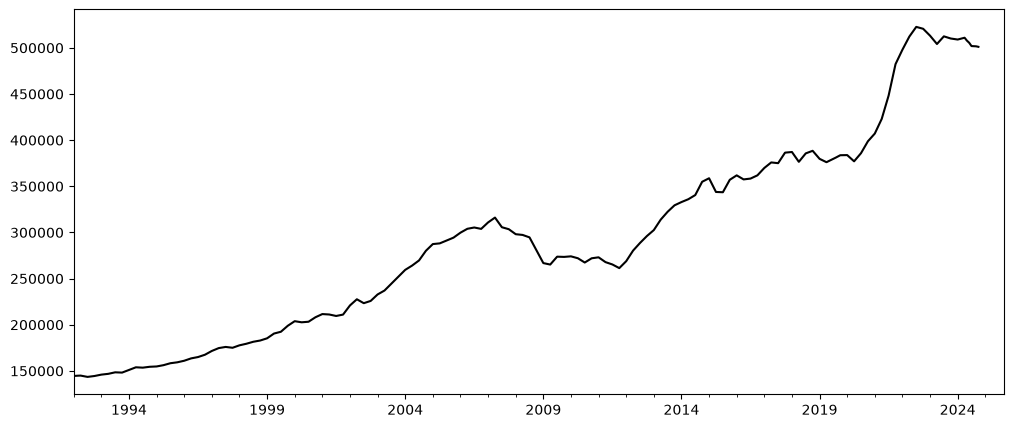

In [38]:
df['Average Sales Price of Houses Sold'].rolling(window=6, min_periods=1, center=True).mean().plot(color='black')

<Axes: >

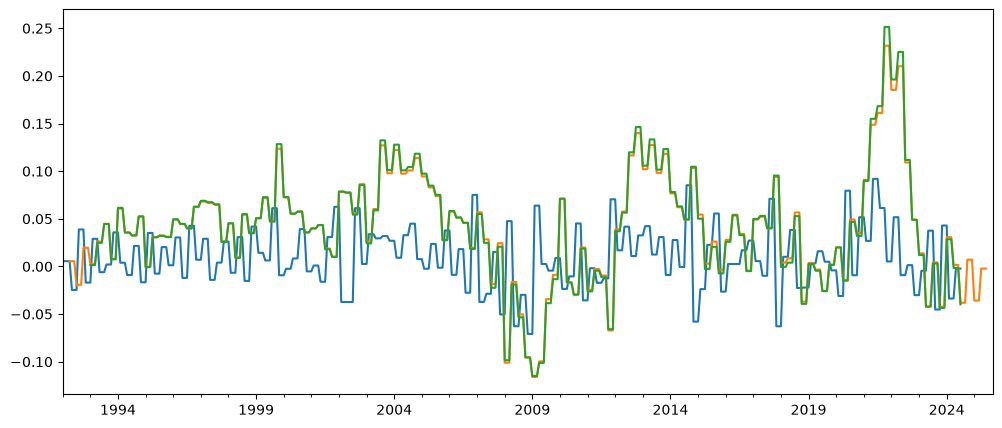

In [39]:
df['Average Sales Price of Houses Sold'].pct_change(fill_method=None).replace(0, np.nan).bfill().plot()
df['Average Sales Price of Houses Sold'].pct_change(fill_method=None).replace(0, np.nan).rolling(window=12, min_periods=1).sum().plot()
((df['Average Sales Price of Houses Sold']/df['Average Sales Price of Houses Sold'].shift(12) - 1)).plot()

<Axes: >

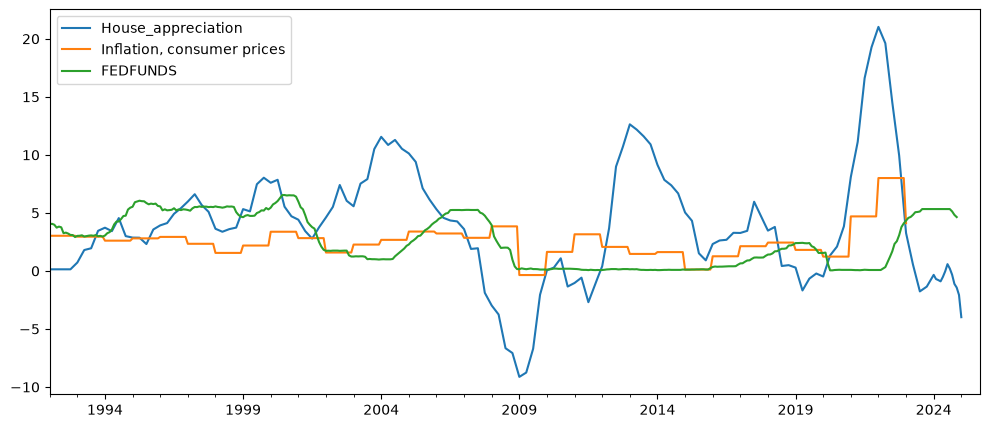

In [40]:
df['House_appreciation'] = (100 * (df['Average Sales Price of Houses Sold']/df['Average Sales Price of Houses Sold'].shift(12) - 1)).bfill()
df['House_appreciation'] = df['House_appreciation'].rolling(window=12, min_periods=1, center=True).mean()
df[['House_appreciation', 'Inflation, consumer prices', 'FEDFUNDS']].plot()
# df[''].plot()
# df[['House_appreciation', 'FEDFUNDS']].plot()

### CPI and inflation

In [41]:
df['Consumer Price Index'] = df['Consumer Price Index'] / 100
df['HF CPI'] = df['HF CPI'] / 100
df['Consumer Price Index'].head()

1992-01-01    1.383
1992-02-01    1.386
1992-03-01    1.391
1992-04-01    1.394
1992-05-01    1.397
Freq: MS, Name: Consumer Price Index, dtype: float64

In [42]:
df['Inflation'] = df['Consumer Price Index'].ffill().pct_change()
df['12M_roll_inflation'] = df['Inflation'].fillna(0).rolling(window=12, min_periods=1, center=True).sum()

<Axes: >

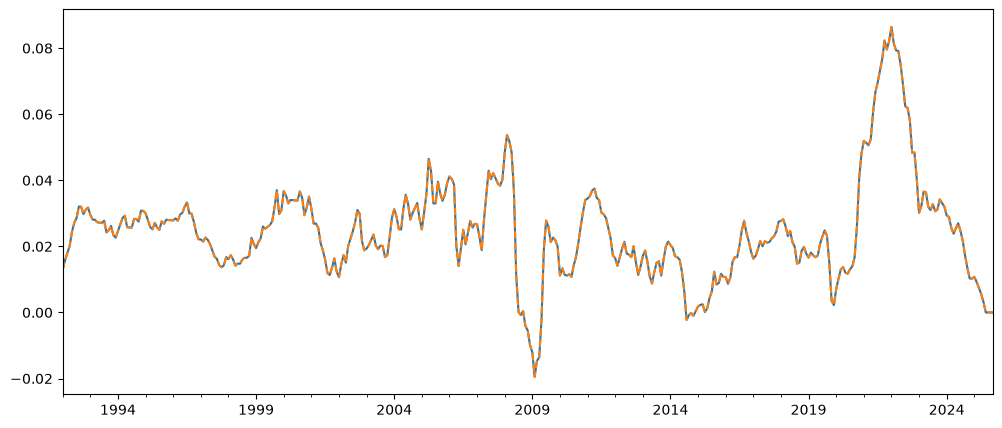

In [43]:
df['Inflation'].rolling(window=12, min_periods=1, center=True).sum().plot()
df['12M_roll_inflation'].plot(linestyle='--')

<Axes: >

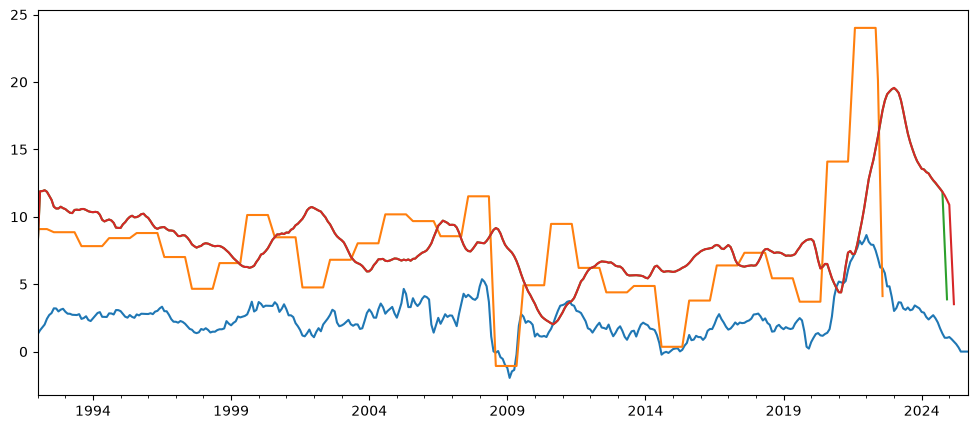

In [44]:
(100 * df['12M_roll_inflation']).plot()
(df['Inflation, consumer prices'].rolling(window=3, min_periods=1, center=True).sum()).shift(-6).plot()
(df['Sticky CPI'].rolling(window=3, min_periods=1, center=True).sum()).plot()
(df['Core Inflation'].rolling(window=3, min_periods=1, center=True).sum()).plot()

In [45]:
df['inferred_infl'] = (df['Personal Consumption Expenditures'].pct_change().rolling(window=12, min_periods=1, center=True).mean() - 
                       df['Real Personal Consumption Expenditures'].pct_change().rolling(window=12, min_periods=1, center=True).mean()
                      )

<Axes: >

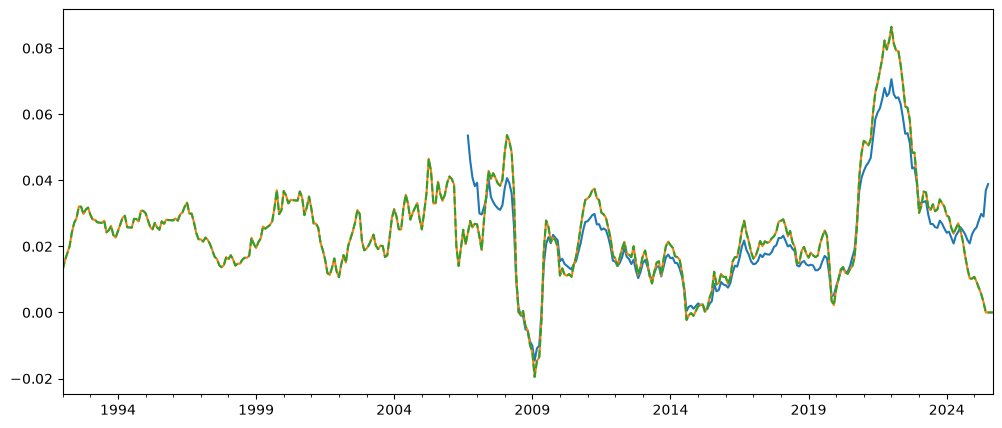

In [46]:
(12 * df['inferred_infl']).plot()
df['Inflation'].rolling(window=12, min_periods=1, center=True).sum().plot()
df['12M_roll_inflation'].plot(linestyle='--')

### Consumption

<Axes: >

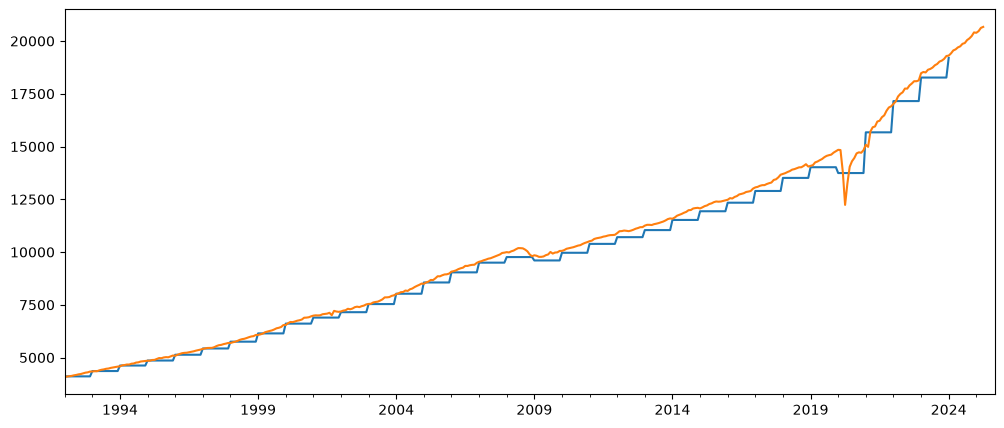

In [47]:
df['Household PCE'].plot()
df['PCE'].plot()

<Axes: >

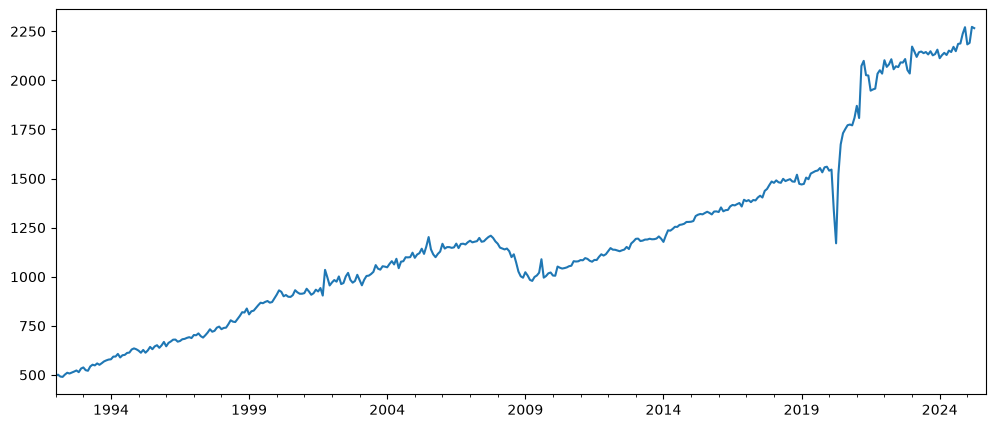

In [48]:
df['PCEDG PCE Durable goods'].plot()

<Axes: >

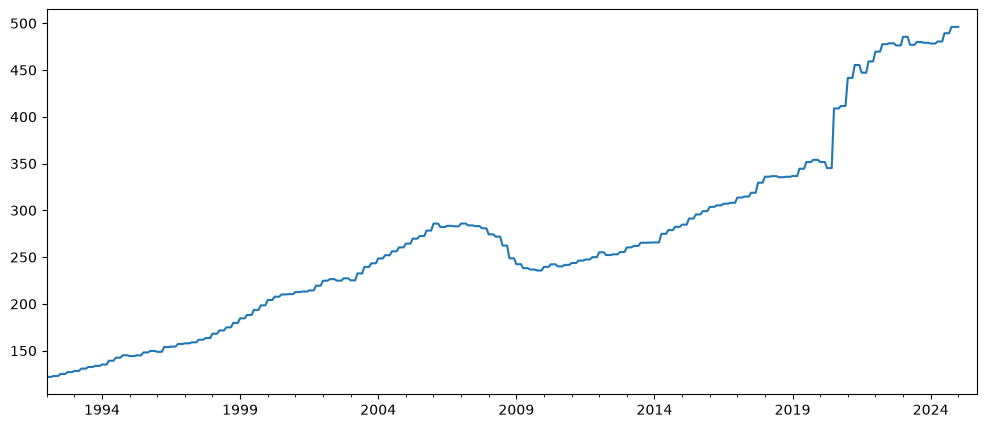

In [49]:
df['PCE Durable goods Furnishings and durable household equipment'].plot()

<Axes: >

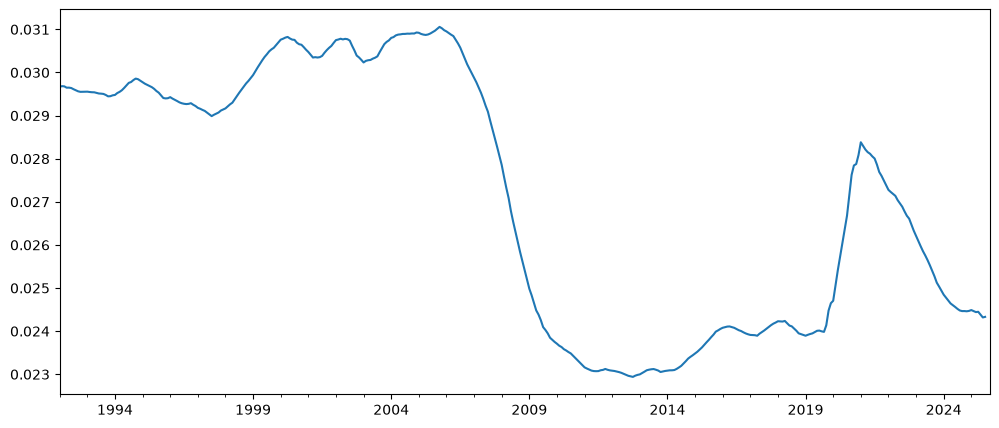

In [50]:
df['Furniture share of PCE'] = (df['PCE Durable goods Furnishings and durable household equipment'] / df['PCE']).rolling(window=12, min_periods=1, center=True).mean()
df['Furniture share of PCE'].plot()

### Income and debt

In [51]:
CPI_factor = df['Consumer Price Index'][df.index.year==2017].mean()

Real personal income per capita               0.990068
Real Disposable Personal Income Per Capita    0.987110
Real gross domestic product per capita        0.962811
Real disposable income per capita             1.000000
Name: Real disposable income per capita, dtype: float64

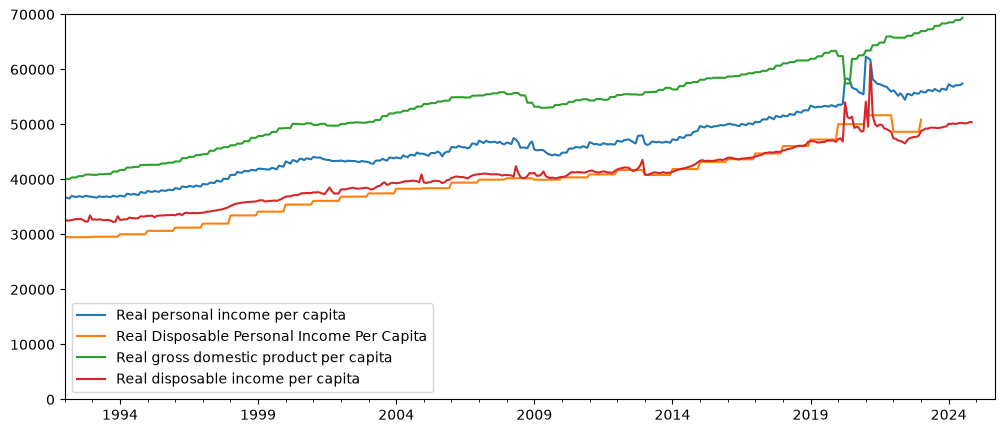

In [52]:
df['Disposable income per capita'] = df['Disposable income'] / df['Population'] * 1e9
df['Real personal income per capita'] = df['Personal income per capita'] / df['Consumer Price Index'] * CPI_factor
df['Real disposable income per capita']= df['Disposable income per capita'] / df['Consumer Price Index'] * CPI_factor

plot_cols = ['Real personal income per capita', 
             'Real Disposable Personal Income Per Capita', 
             'Real gross domestic product per capita', 
             'Real disposable income per capita'
            ]

df[plot_cols].plot()
plt.ylim([0,70000])
plt.legend()
df[plot_cols].corr().iloc[:,-1]

<Axes: >

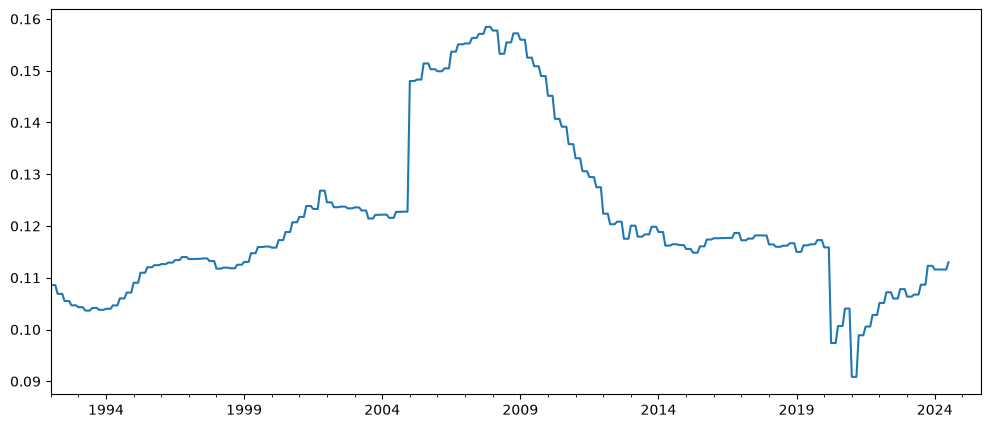

In [53]:
df['Household Debt Service Percent of Disp Income'] = df['Household Debt Service Percent of Disp Income'] / 100
df['Household Debt Service Percent of Disp Income'].plot()

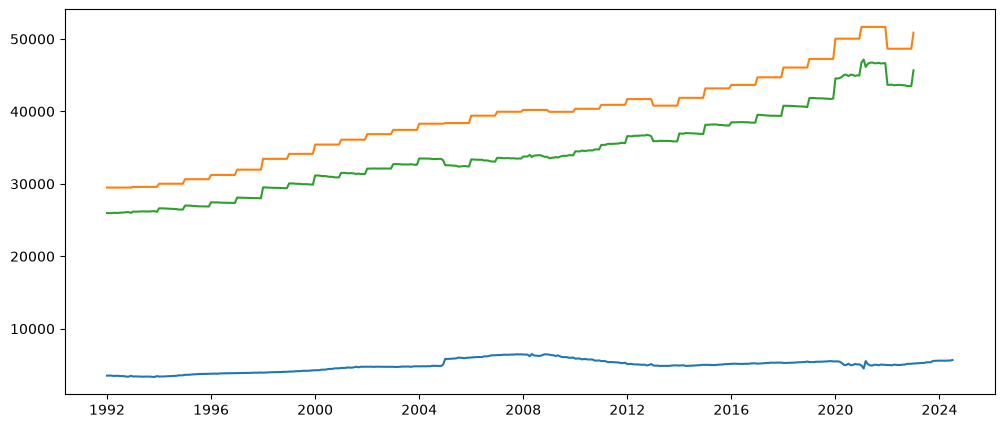

In [54]:
df['Real Household Debt Service'] = df['Household Debt Service Percent of Disp Income'] * df['Real disposable income per capita']
df['Real Usable Personal Income'] = df['Real Disposable Personal Income Per Capita'] - df['Real Household Debt Service']

plt.plot(df[['Real Household Debt Service', 'Real Disposable Personal Income Per Capita', 'Real Usable Personal Income']])
# plt.yscale('log')

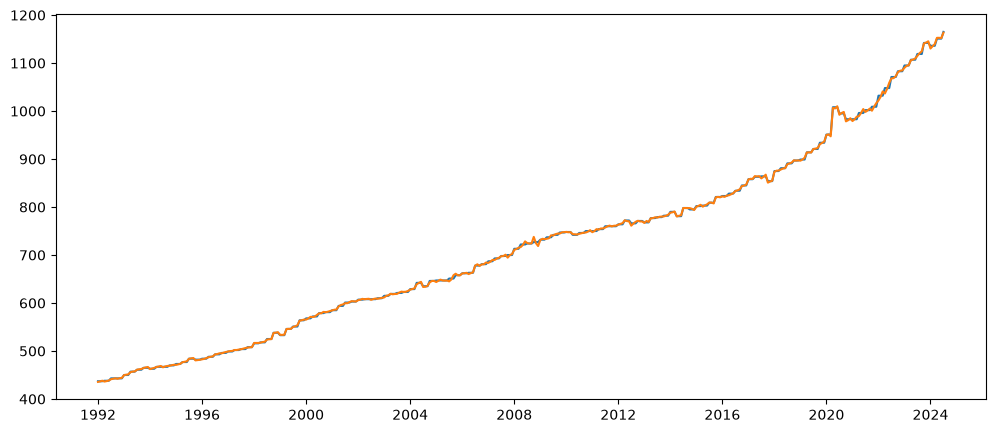

In [55]:
plt.plot(df['FTE Median usual weekly nom earnings'])
plt.plot(df['FTE Median usual weekly real earnings']*df['Consumer Price Index'])

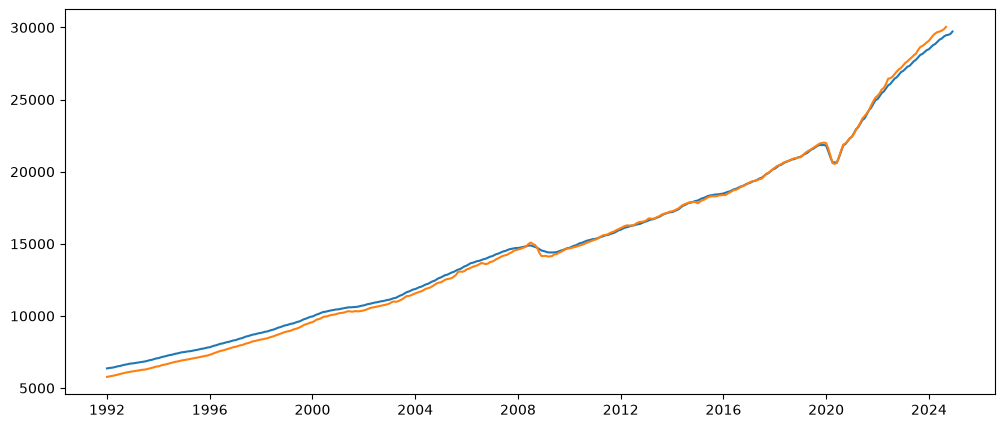

In [56]:
plt.plot(df['GDP'])
plt.plot(df['GDP_infl_adj']*df['Consumer Price Index']/CPI_factor)

<Axes: >

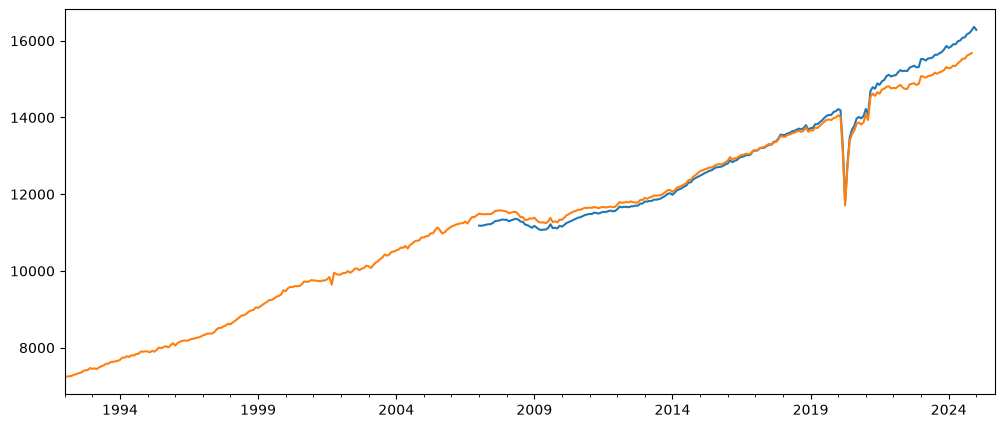

In [57]:
df['Real Personal Consumption Expenditures'].plot()
(df['Personal Consumption Expenditures'] / df['Consumer Price Index'] * CPI_factor).plot()

In [58]:
df['Real Personal Consumption Expenditures'] = df['Personal Consumption Expenditures'] / df['Consumer Price Index'] * CPI_factor

In [59]:
df['Personal Consumption Expenditures per capita'] = df['Personal Consumption Expenditures'] / df['Population'] * 1e6
df['Real Personal Consumption Expenditures per capita'] = df['Real Personal Consumption Expenditures'] / df['Population'] * 1e6
df['Real Personal Consumption Expenditures per household'] = df['Real Personal Consumption Expenditures'] / df['Households'] * 1e6

<Axes: >

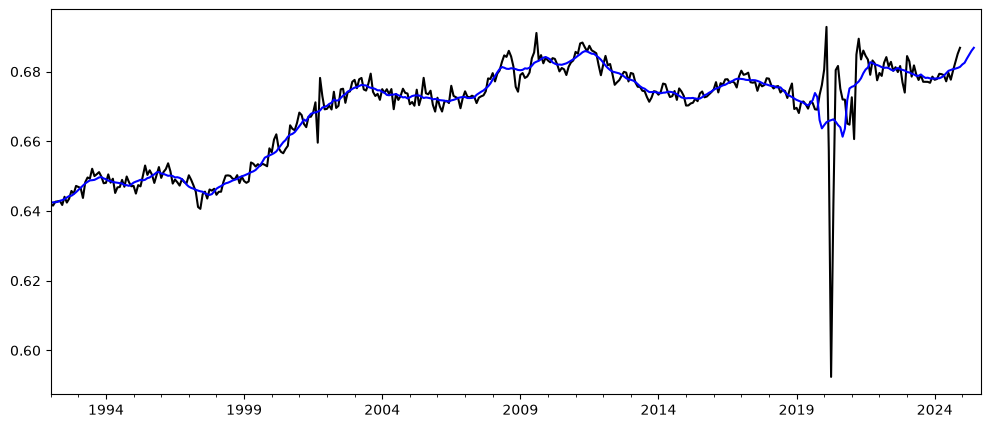

In [60]:
df['Consumption as share of GDP'] = df['Personal Consumption Expenditures'] / df['GDP']
df['roll_Consumption as share of GDP'] = df['Consumption as share of GDP'].rolling(window=12, min_periods=1, center=True).mean()

df['Consumption as share of GDP'].plot(color='black')
df['roll_Consumption as share of GDP'].plot(color='blue')

In [61]:
df['roll_Consumption exp as share of GDP'] = df['Personal consumption expenditures as share of GDP'].rolling(window=12, min_periods=1, center=True).mean() / 100

<Axes: >

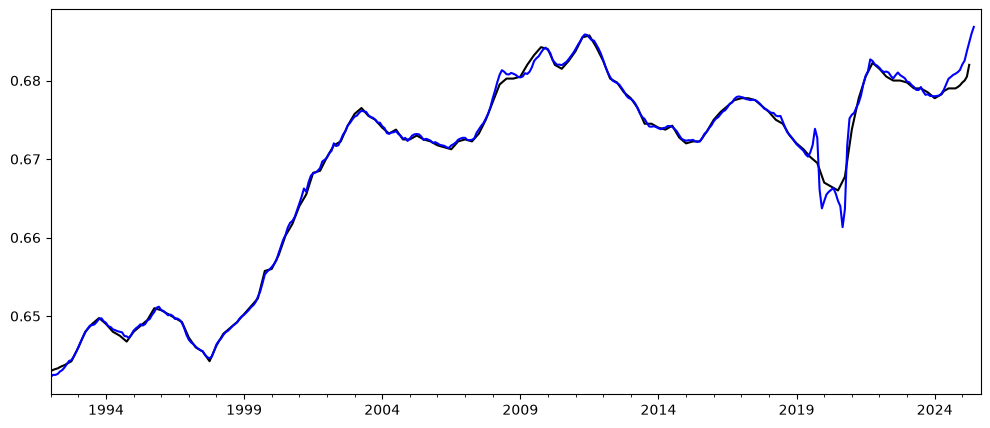

In [62]:
df['roll_Consumption exp as share of GDP'].plot(color='black')
df['roll_Consumption as share of GDP'].plot(color='blue')

### Y - Time series decomposition

In [63]:
df['Retail Sales Furniture & HF'][abs(df['Retail Sales Furniture & HF'].diff()) > 4000]

2020-04-01    3780.0
Freq: MS, Name: Retail Sales Furniture & HF, dtype: float64

In [64]:
df['Retail Sales Furniture & HF corr'] = df['Retail Sales Furniture & HF']
df.loc['2020-04-01', 'Retail Sales Furniture & HF corr'] = 11000
df.loc['2020-05-01', 'Retail Sales Furniture & HF corr'] = 11000

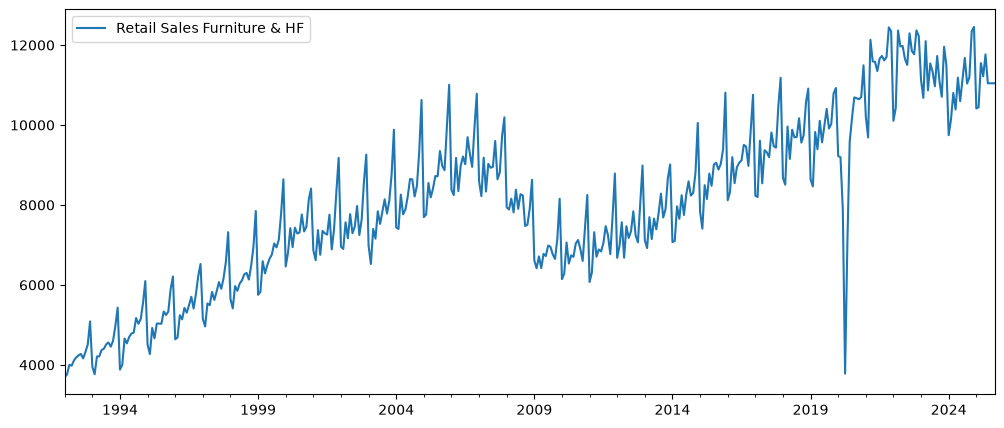

In [65]:
df['Retail Sales Furniture & HF'].plot()
plt.legend()

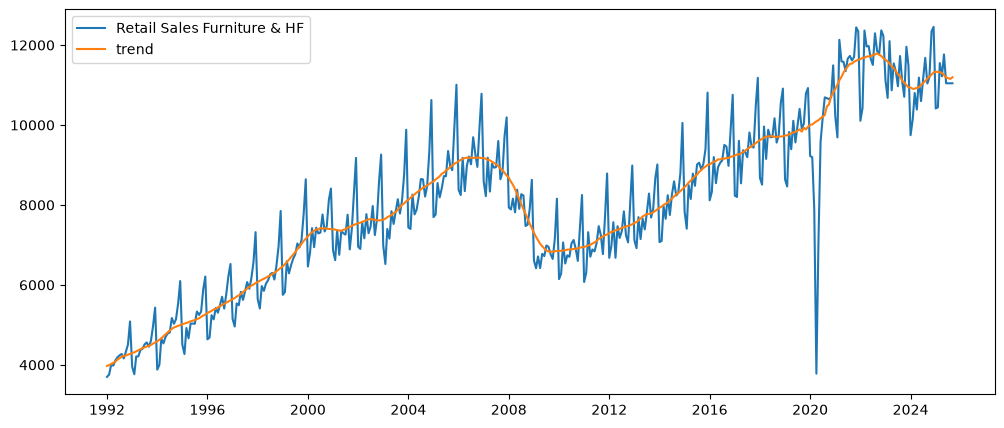

In [66]:
trend_series = df['Retail Sales Furniture & HF corr'].rolling(window=12, min_periods=1, center=True).mean()
trend_series = (trend_series.shift(1).bfill() + trend_series.shift(-1).ffill()) / 2

plt.plot(df['Retail Sales Furniture & HF'], label='Retail Sales Furniture & HF')
plt.plot(trend_series, label='trend')
plt.legend()

In [67]:
trend_series[abs(trend_series.diff()) > 200]

2020-09-01    10468.541667
2020-11-01    10714.541667
Name: Retail Sales Furniture & HF corr, dtype: float64

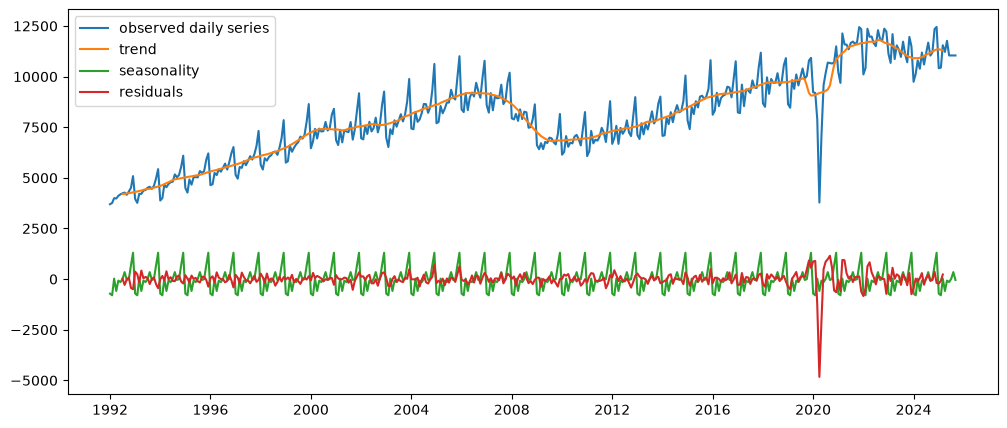

In [68]:
decomposition = seasonal.seasonal_decompose(df['Retail Sales Furniture & HF'], model='additive')

plot_dict = {'observed daily series': decomposition.observed, 
             'trend': decomposition.trend, 
             'seasonality':decomposition.seasonal, 
             'residuals': decomposition.resid
            }

# for i, val in enumerate(plot_dict.keys()):
#     ax[i].plot(plot_dict[val])
#     ax[i].set_title(val)

for i, val in enumerate(plot_dict.keys()):
    plt.plot(plot_dict[val], label=val)

plt.legend();

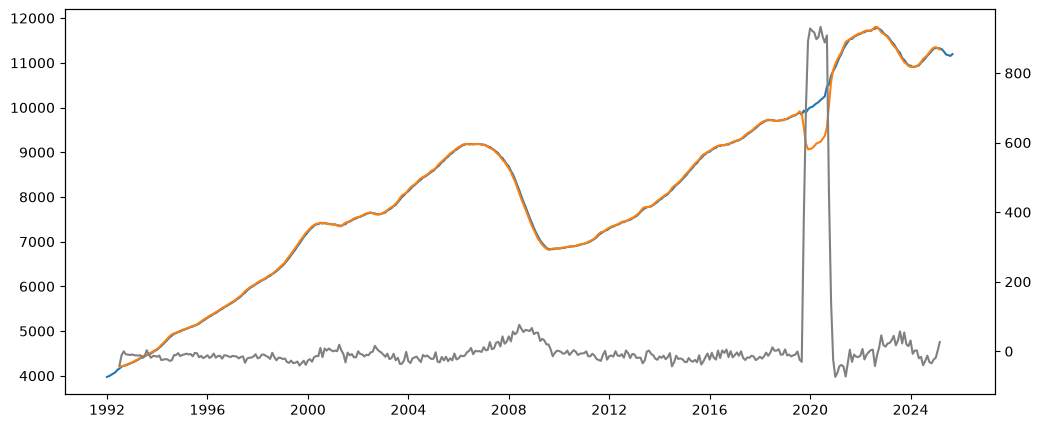

In [69]:
fig, ax1 = plt.subplots()

ax1.plot(trend_series)
ax1.plot(decomposition.trend)
ax2 = ax1.twinx()
ax2.plot(trend_series - decomposition.trend, 'grey')

In [70]:
rest_series = df['Retail Sales Furniture & HF'] - trend_series
# for_seasonal_series = rest_series[~rest_series.isin(rest_series.nsmallest(2))]

date_objects = [datetime.strptime(date, "%Y-%m-%d").date() for date in ['2020-03-01', '2020-04-01', '2020-05-01']]
for_seasonal_series = rest_series[~rest_series.index.isin(date_objects)]

grouped_series = for_seasonal_series.groupby(for_seasonal_series.index.month).mean().reset_index()
grouped_series.rename({'index':'month', 0:'Seasonal Sales'}, axis=1, inplace=True)

dates_df = pd.DataFrame(rest_series.index)
dates_df.columns = ['dates']
dates_df['dates'] = pd.to_datetime(dates_df['dates'])
dates_df['month'] = dates_df['dates'].dt.month

dates_df = dates_df.merge(grouped_series, how='left', on='month')
dates_df.set_index('dates', inplace=True)
seasonal_series = dates_df['Seasonal Sales']

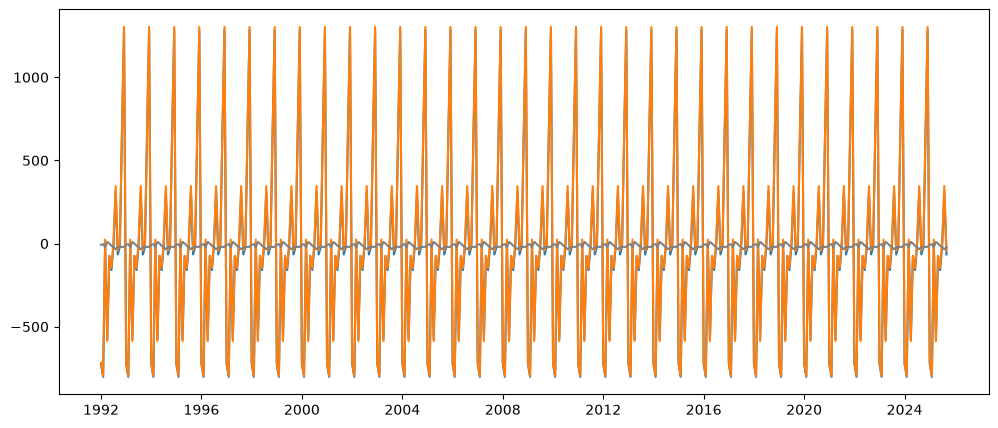

In [71]:
fig, ax1 = plt.subplots()

ax1.plot(seasonal_series)
ax1.plot(decomposition.seasonal)
# ax2 = ax1.twinx()
ax1.plot(seasonal_series - decomposition.seasonal, 'grey')

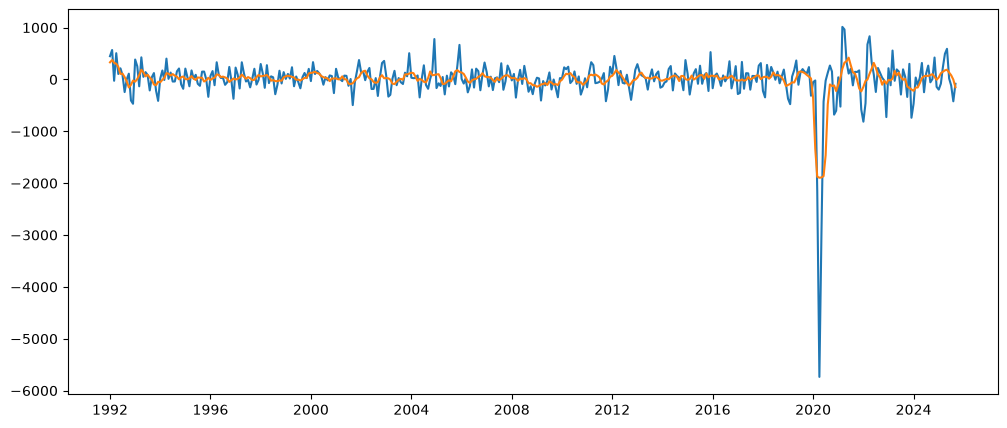

In [72]:
res_series = rest_series - seasonal_series
roll_res_series = res_series.rolling(window=6, min_periods=1, center=True).mean()
plt.plot(res_series)
plt.plot(roll_res_series)

In [73]:
df['Y'] = trend_series # + roll_res_series

In [74]:
df['Y_infl_adj'] = df['Y'] / df['Consumer Price Index']

<Axes: >

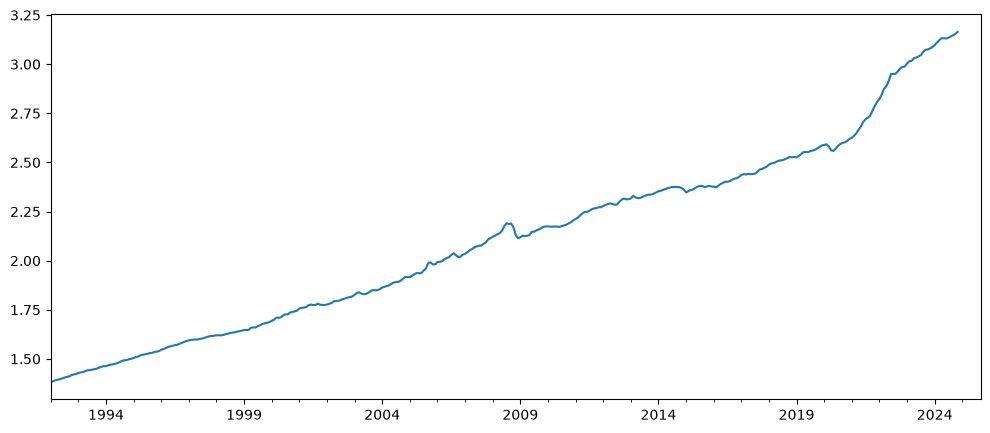

In [75]:
df['Consumer Price Index'].plot()

### Exporting the df

In [76]:
original_columns = df.columns

In [77]:
exit_path = "C:/Users/illoi/Escritorio-2/00 - RETAIL INSIGHTS & ANALYTICS/01 - MARKET ANALYSIS/Data/US - Copy"
file_name = 'prov2.csv'
sep = ','

df.to_csv(os.path.join(exit_path, file_name), sep=sep)


gr_df = df.groupby(df.index.year)[['Retail Sales Furniture & HF', 'Real Estate - market sales', 'US All home sales']].sum()
file_name = 'gr_prov.csv'
gr_df.to_csv(os.path.join(exit_path, file_name), sep=sep)

### Adding the diff columns

In [78]:
original_cols = df.columns

In [79]:
diff_df = pd.DataFrame()
pct_df = pd.DataFrame()
roll_pct_df = pd.DataFrame()

diff_df = df.diff()
pct_df = df.pct_change(fill_method=None)
roll_pct_df = df.pct_change(fill_method=None).rolling(window=12, min_periods=1, center=True).mean()

diff_df.rename(columns=dict(zip(diff_df.columns,'diff_' + diff_df.columns)), inplace=True)
pct_df.rename(columns=dict(zip(pct_df.columns,'pct_chg_' + pct_df.columns)), inplace=True)
roll_pct_df.rename(columns=dict(zip(roll_pct_df.columns,'roll_pct_chg_' + roll_pct_df.columns)), inplace=True)

df = pd.concat([df, diff_df, pct_df, roll_pct_df], axis=1)